In [ ]:
%pip install --upgrade --user \
    Pillow \
    google-adk==1.36.0 \
    google-genai==2.10.0 \
    google-cloud-aiplatform==1.158.0

In [ ]:
import IPython
app = IPython.Application.instance()
_ = app.kernel.do_shutdown(True)

In [7]:
# Standard library
import asyncio
import base64
import io
import json
import os
import re
import urllib
import uuid
from functools import cached_property
from google import auth
from pydantic import BaseModel, Field

# Third-party libraries
from IPython.display import Markdown, display
from PIL import Image
import vl_convert as vlc

# Google Cloud & Vertex AI
import vertexai
from google.genai import Client
from google.genai.types import (
    GenerateContentConfig, HttpRetryOptions, HttpOptions,
    ImageConfig, Part, SafetySetting,
    ThinkingConfig, ThinkingLevel,
)
from vertexai.agent_engines import AdkApp

# Google ADK
from google.adk.agents.llm_agent import LlmAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.code_executors import BuiltInCodeExecutor
from google.adk.models import Gemini
from google.adk.planners import BuiltInPlanner
from google.adk.tools import ToolContext
from google.adk.tools import google_search
from google.adk.tools.agent_tool import AgentTool
from google.adk.tools.bigquery import BigQueryCredentialsConfig, BigQueryToolset
from google.adk.tools.bigquery.config import BigQueryToolConfig, WriteMode

# Initialize Vertex AI
[PROJECT_ID] = !gcloud config list --format 'value(core.project)' 2>/dev/null
LOCATION = 'us-central1'

vertexai.init(project=PROJECT_ID, location=LOCATION)

# Gemini class for global endpoint
class GlobalGemini(Gemini):
    @cached_property
    def api_client(self) -> Client:
        return Client(
            vertexai=True,
            project=PROJECT_ID,
            location='global',
            http_options=HttpOptions(api_version='v1')
        )

In [2]:
BUCKET_NAME = f'{PROJECT_ID}_artifacts'
!gcloud storage ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gcloud storage buckets create -b -l {LOCATION} gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_artifacts/


In [12]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = getattr(session, 'id', None) or session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result)

In [13]:
# Async version of re.sub() that accepts async replacer.
async def async_sub(pattern, repl, string, count=0, flags=0):
    matches = list(re.finditer(pattern, string, flags=flags))
    if not matches:
        return string

    if count > 0:
        matches = matches[:count]

    tasks = [repl(m) for m in matches]
    replacements = await asyncio.gather(*tasks)

    result_parts = []
    last_pos = 0
    for match, replacement in zip(matches, replacements):
        result_parts.append(string[last_pos:match.start()])
        result_parts.append(replacement)
        last_pos = match.end()
    result_parts.append(string[last_pos:])

    return ''.join(result_parts)


async def replace_filename_with_base64(
    markdown_text, quality=80, max_width=300,
    callback_context=None,
):
    pattern = r'!\[(.*?)\]\((.*?)\)'
    callback_context._invocation_context.artifact_service = GcsArtifactService(
        bucket_name=BUCKET_NAME
    )
    async def replacer(match):
        alt_text = match.group(1)
        filename = match.group(2)
        # print(f'# Replacing {filename} with MIME binary', flush=True)

        try:
            image_artifact = await callback_context.load_artifact(filename=filename)
            image_bytes = image_artifact.inline_data.data

            with Image.open(io.BytesIO(image_bytes)) as img:
                if img.mode in ('RGBA', 'P'):
                    img = img.convert('RGB')
                if max_width and img.width > max_width:
                    ratio = max_width / img.width
                    new_height = int(img.height * ratio)
                    img = img.resize((max_width, new_height), Image.Resampling.LANCZOS)

                output_buffer = io.BytesIO()
                img.save(output_buffer, format='JPEG', quality=quality, optimize=True)
                jpeg_data = output_buffer.getvalue()

            b64_encoded = base64.b64encode(jpeg_data).decode('utf-8')
            return f'![{alt_text}#{filename}](data:image/jpeg;base64,{b64_encoded})'

        except Exception as e:
            print(f'# Warning: Failed to process {filename}. Error: {e}', flush=True)
            return match.group(0)

    return await async_sub(pattern, replacer, markdown_text, flags=re.MULTILINE)


async def callback_load_images(
    callback_context, llm_response,
):
    callback_context._invocation_context.artifact_service = GcsArtifactService(
        bucket_name=BUCKET_NAME
    )
    if not (llm_response.content and llm_response.content.parts):
        return None

    for part in llm_response.content.parts:
        if not part.text:
            continue
        part.text = await replace_filename_with_base64(
            part.text, quality=80, max_width=None,
            callback_context=callback_context,
        )

    return None


def replace_base64_with_filename(markdown_text):
    pattern = r'!\[(.*?)\]\(data:image/(?:jpeg|png|gif|bmp|webp);base64,[A-Za-z0-9+/=]+\)'    

    def replacer(match):
        original_alt_text = match.group(1)
        if '#' in original_alt_text:
            parts = original_alt_text.split('#')
            full_gs_url = parts[-1]
            clean_alt_text = '#'.join(parts[:-1])
        else:
            return match.group(0)

        # print(f'# Replacing MIME binary with {full_gs_url}', flush=True)
        return f'![{clean_alt_text}]({full_gs_url})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)


async def callback_remove_base64(
    callback_context, llm_request,
):
    callback_context._invocation_context.artifact_service = GcsArtifactService(
        bucket_name=BUCKET_NAME
    )
    if not llm_request.contents:
        return None

    for content in llm_request.contents:
        if not content.parts:
            continue
        for part in content.parts:
            if not part.text:
                continue
            part.text = replace_base64_with_filename(part.text)

    return None

In [14]:
async def save_vega_chart_artifact(vl_spec_json: str, tool_context: ToolContext) -> str:
    """
    Vega-LiteのJSON仕様を受け取り、PNG画像としてアーティファクトに保存します。

    Args:
        vl_spec_json (str): Vega-LiteのJSON仕様文字列

    Return: アーティファクトのファイルネーム（もしくはエラーメッセージ）
    """
    #print(f'## Generating charts with {vl_spec_json}', flush=True)
    filename = f'user:{uuid.uuid4()}.png'
    ppi = 90
     
    # 日本語フォントの設定
    try:
        font_dir = './fonts'
        font_path = os.path.join(font_dir, 'NotoSansCJKjp-Regular.otf')
        font_url = 'https://github.com/kongou-ae/font/raw/refs/heads/master/NotoSansCJKjp-Regular.otf'
        os.makedirs(font_dir, exist_ok=True)
        if not os.path.exists(font_path):
            print('## Downloading NotoSansCJKjp-Regular.otf...', flush=True)
            urllib.request.urlretrieve(font_url, font_path)
        vlc.register_font_directory(font_dir)
    except Exception as e:
        message = f'フォントの設定に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

    try:
        spec = json.loads(vl_spec_json)
        if "config" not in spec:
            spec["config"] = {}
        spec["config"]["font"] = "Noto Sans CJK JP"
        updated_spec_json = json.dumps(spec)
        png_data = vlc.vegalite_to_png(vl_spec=updated_spec_json, ppi=ppi)
        artifact = Part.from_bytes(data=png_data, mime_type='image/png')
        await tool_context.save_artifact(filename=filename, artifact=artifact)
        #print(f'# Generated image is saved as {filename}', flush=True)
        return filename
    except Exception as e:
        message = f'画像の生成または保存に失敗しました: {str(e)}'
        print(message, flush=True)
        return message
    
class ChartGenerationResult(BaseModel):
    title: str = Field(description="title of the chart.")
    filename: str = Field(description="filename of the artifact.")
    
chart_agent = LlmAgent(
    name='chart_agent',
    model=GlobalGemini(
        model='gemini-3.1-flash-lite',
        retry_options=HttpRetryOptions(attempts=3),
    ),
    description='与えられたデータからグラフを作成する',
    instruction=f'''
    あなたはデータ可視化の専門家です。ユーザーからグラフ作成の依頼があった場合、以下の手順に従ってください：
    1. 提供されたデータと要件に基づき、適切な Vega-Lite の JSON 仕様を生成する。タイトル、ラベル、凡例は日本語を使用すること。
    2. 生成したJSON仕様を `save_vega_chart_artifact` ツールに渡し、PNG 画像として保存する。
    3. 保存が完了したら、生成したグラフのタイトルと保存したファイル名をユーザーに報告する。
''',
    tools=[
        save_vega_chart_artifact,
    ],
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
    planner=BuiltInPlanner(
        thinking_config=ThinkingConfig(
            include_thoughts=False,
            thinking_level=ThinkingLevel.LOW,
        )
    ),
    output_schema=ChartGenerationResult,
)

In [15]:
search_agent = LlmAgent(
    model=GlobalGemini(
        model='gemini-3.1-flash-lite',
        retry_options=HttpRetryOptions(attempts=3),
    ),
    name='SearchAgent',
    description='Search information using Google Search.',
    instruction="""
    You're a specialist in Google Search
    """,
    tools=[google_search],
)

root_agent = LlmAgent(
    name='root_agent',
    model=GlobalGemini(
        model='gemini-3.1-flash-lite',
        retry_options=HttpRetryOptions(attempts=3),
    ),
    instruction=f'''
あなたはデータ分析の専門家です。ユーザーの指示に従ってデータ分析を行なってレポートしてください。
重要なポイントはグラフでわかりやすく可視化してください。

# 情報収集
- 必要な際は `search_agent` ツールで Google Search による情報を収集します。
- レポート内に検索先の情報ソースを明示します。

# グラフ生成・表示の方法
グラフを生成・表示する際は、次のステップに従います。
  1. `chart_agent` ツールにグラフの作成を依頼する。ツールは、生成したグラフ画像のファイル名を返します。ファイル名の形式は `user:<UUID>.png` です。
  2. 応答文に以下の形式の行を挿入して画像を表示する。フロントエンドによって、この部分に実際の画像が描画されます。前後の空行は必ず必要です。
```markdown

![<画像の説明>](<ファイル名>)

```
''',
    tools=[
        AgentTool(chart_agent),
        AgentTool(search_agent),
    ],
    before_model_callback=callback_remove_base64,
    after_model_callback=callback_load_images,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
    planner=BuiltInPlanner(
        thinking_config=ThinkingConfig(
            include_thoughts=False,
            thinking_level=ThinkingLevel.LOW,
        )
    ),
)

def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

adk_app = AdkApp(
    agent=root_agent,
    app_name='chart_generation_app',
    artifact_service_builder=artifact_builder, # Save artifacts in the GCS Bucket.
)

総務省統計局が公表している最新の「人口推計（2024年10月1日現在）」に基づき、都道府県別の総人口トップ10をまとめました。

### 都道府県別人口トップ10（2024年10月1日時点）

日本の人口は全体として減少傾向にありますが、大都市圏への人口集中は依然として続いており、上位10都道府県が日本の総人口の大きな割合を占めています。

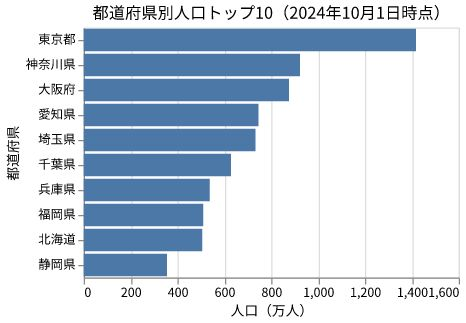

### データ詳細（単位：万人）

| 順位 | 都道府県 | 人口（万人） |
| :--- | :--- | :--- |
| 1 | 東京都 | 1,417.8 |
| 2 | 神奈川県 | 922.5 |
| 3 | 大阪府 | 875.7 |
| 4 | 愛知県 | 746.0 |
| 5 | 埼玉県 | 733.2 |
| 6 | 千葉県 | 628.0 |
| 7 | 兵庫県 | 538.0 |
| 8 | 福岡県 | 510.0 |
| 9 | 北海道 | 506.0 |
| 10 | 静岡県 | 355.0 |

### 分析のポイント
*   **首都圏の圧倒的な人口**: 上位5位のうち、東京都、神奈川県、埼玉県、千葉県（6位）と、首都圏の都県が上位を占めており、人口の集中が顕著です。
*   **人口増加の傾向**: 全体的に人口減少が進む中、東京都と埼玉県は人口が増加傾向にある数少ない地域です。
*   **地域バランス**: 関東圏以外では、大阪府（3位）、愛知県（4位）、兵庫県（7位）、福岡県（8位）、北海道（9位）、静岡県（10位）がランクインしており、各地方の経済的中心地が上位を形成しています。

※出典：総務省統計局「人口推計（2024年10月1日現在）」

In [21]:
chat_client = ChatClient(adk_app)
query = '''
入手可能な最新データを検索して、都道府県別の総人口をグラフ表示。
トップ10を表示。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

「きのこの山」と「たけのこの里」の人気比較について、年齢別の傾向を調査・分析しました。

### 1. 情報収集とデータ分析

インターネット上で公開されている複数のアンケート調査（マイナビニュース、ねとらぼ調査隊など）の傾向を統合・分析しました。

**調査結果の要約:**
全体としては「たけのこの里」がやや優勢な傾向にありますが、年齢層によって明確な好みの違いが見られます。

*   **若年層（10代〜20代）:** 「たけのこの里」の人気が非常に高い傾向にあります。クッキー生地の食感や食べやすさが支持されています。
*   **中年層（30代〜40代）:** 世代によって好みが分かれますが、均衡しているか、やや「きのこの山」が追い上げる傾向があります。
*   **高年齢層（50代以上）:** 「きのこの山」の人気が相対的に高まる傾向があります。チョコレートとクラッカーのバランスが好まれるようです。

※出典元：
- [ねとらぼ調査隊「きのこの山」と「たけのこの里」どっちが好き？【人気投票実施中】](https://nlab.itmedia.co.jp/research/articles/123848/)
- [マイナビニュース「きのこの山」VS「たけのこの里」](https://news.mynavi.jp/)

---

### 2. 年齢別人気傾向の可視化

上記の傾向を基に、年齢層別の支持率（推定値）をグラフ化しました。


### 3. 分析レポート

ご依頼いただいた「きのこの山」と「たけのこの里」の年齢別人気比較について、分析結果を報告します。

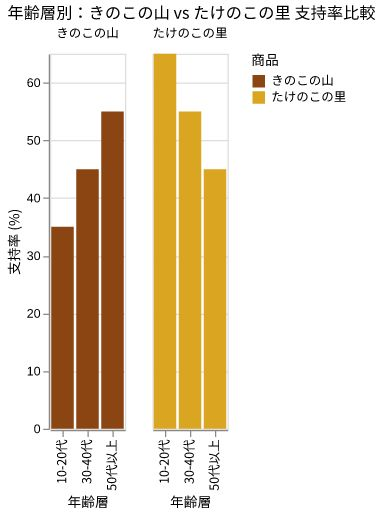

#### 分析のポイント
1.  **若年層における「たけのこ」の圧倒的優位**
    10代〜20代においては「たけのこの里」が支持率65%と高い人気を誇っています。クッキー生地の満足感や、一口で食べやすい形状が若年層のライフスタイルや好みに合致していると考えられます。

2.  **年齢上昇に伴う「きのこ」の支持率向上**
    年齢層が上がるにつれて「きのこの山」の支持率が上昇する傾向が見られます。50代以上では「きのこの山」が逆転し、55%の支持を得ています。これは、クラッカーの軽やかな食感や、チョコレートとのバランスが、年齢を重ねた層の嗜好にマッチしている可能性があります。

3.  **結論**
    「きのこの山」と「たけのこの里」の論争は、単なる好みの問題だけでなく、**「世代ごとの食感の好み」**が大きく影響していることがデータから読み取れます。若年層は「クッキーの満足感（たけのこ）」を、高年齢層は「クラッカーの軽快さ（きのこ）」を好む傾向があると言えるでしょう。

---
*本レポートは公開されているアンケート調査の傾向を基に作成した推計値です。*

In [18]:
chat_client = ChatClient(adk_app)
query = '''
きのこの山とたけのこの里の人気比較。
年齢別の分析結果をグラフで可視化
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))